In [1]:
import pandas as pd
import numpy as np 
import json
from data.asset import Asset
from data.processor import calculate_features
from strategy.generator import strategyname, MeanReversionStrategy, TrendFollowingStrategy
from performance.backtest import Backtester
from performance.metrics import max_drawdown, buy_and_hold, sharpe_ratio

In [2]:
with open("config.json") as f:
    config = json.load(f)

In [3]:

stock = Asset(ticker=config["ticker"], start=config["start"], end=config["end"])


In [4]:
stock.load_price_data()
stock.data = calculate_features(stock.data)

               mean  count       sum
direction                           
-1.0      -0.002257    442 -0.997632
 0.0      -0.034895      2 -0.069790
 1.0       0.000434    429  0.185974
    lb_stat  lb_pvalue
1  1.659157   0.197717


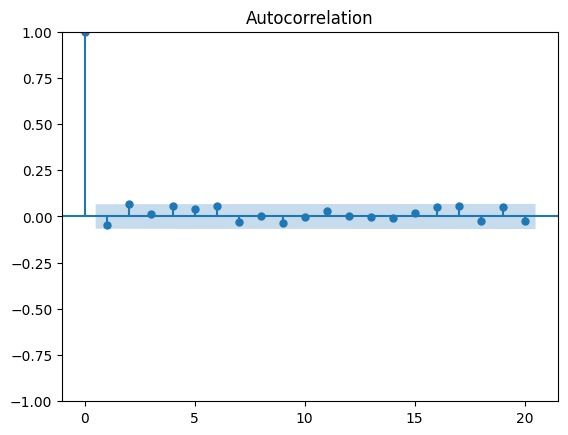

In [5]:
mean_rev_strat = MeanReversionStrategy(stock.data)
mean_rev_strat.run()

               mean  count       sum
direction                           
-1.0      -0.002257    442 -0.997632
 0.0      -0.034895      2 -0.069790
 1.0       0.000434    429  0.185974
    lb_stat  lb_pvalue
1  1.659157   0.197717


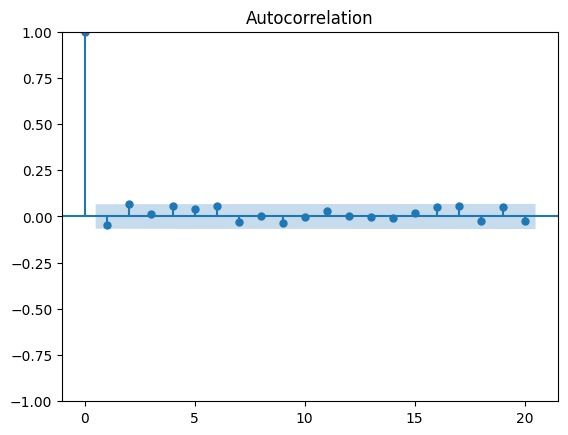

In [6]:
trend_follow_strat = TrendFollowingStrategy(stock.data)
trend_follow_strat.run()

In [7]:
Backtester(stock.data, strategyname.MEAN_REVERSION, config["transaction_cost"]).test()

{'# winning trades': np.int64(455),
 '# losing trades': np.int64(416),
 '# neutral trades': np.int64(2),
 '# na trades': np.int64(0),
 '# total trades': np.int64(873),
 'win_rate': np.float64(0.5211912943871707)}

In [8]:
Backtester(stock.data, strategyname.TREND_FOLLOWING, config["transaction_cost"]).test()

{'# winning trades': np.int64(381),
 '# losing trades': np.int64(490),
 '# neutral trades': np.int64(2),
 '# na trades': np.int64(0),
 '# total trades': np.int64(873),
 'win_rate': np.float64(0.436426116838488)}

{'max_drawdown': np.float64(-0.9299812729672405),
 'peak_date': Timestamp('2017-11-13 00:00:00+0000', tz='UTC'),
 'trough_date': Timestamp('2020-03-12 00:00:00+0000', tz='UTC')}

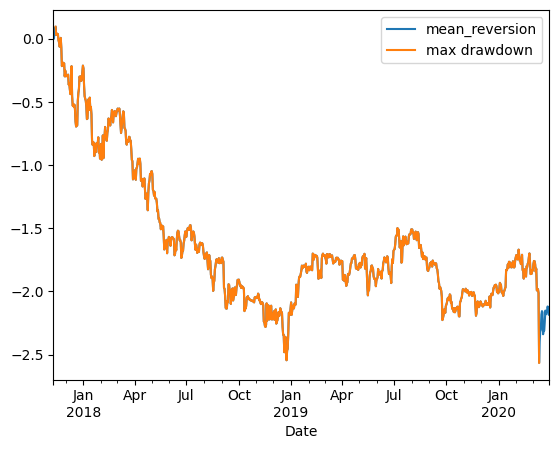

In [9]:
max_drawdown(stock.data, strategyname.MEAN_REVERSION)

{'max_drawdown': np.float64(-0.8367951150707525),
 'peak_date': Timestamp('2018-12-24 00:00:00+0000', tz='UTC'),
 'trough_date': Timestamp('2020-02-24 00:00:00+0000', tz='UTC')}

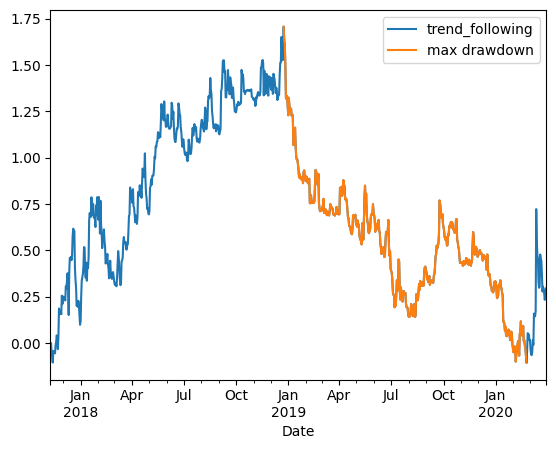

In [10]:
max_drawdown(stock.data, strategyname.TREND_FOLLOWING)

np.float64(-0.8814485616717758)

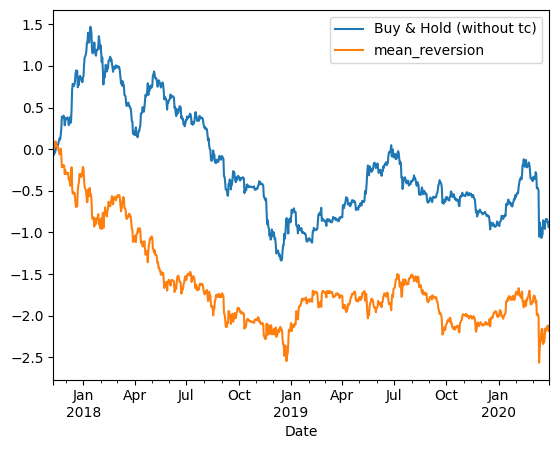

In [11]:
buy_and_hold(stock.data, strategyname.MEAN_REVERSION)

np.float64(-0.8814485616717758)

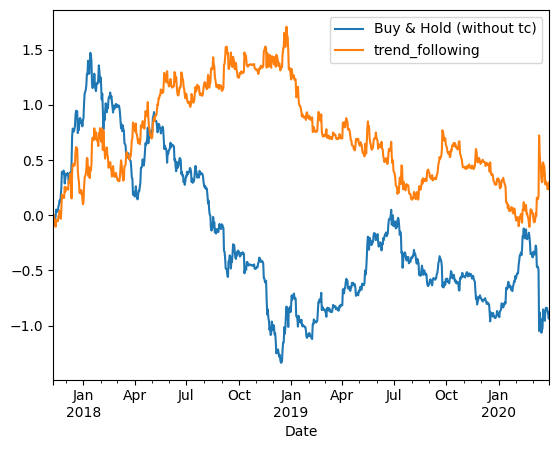

In [12]:
buy_and_hold(stock.data, strategyname.TREND_FOLLOWING)

In [13]:
sharpe_ratio(stock.data, strategyname.MEAN_REVERSION)

np.float64(-0.04486667125544116)

In [14]:
sharpe_ratio(stock.data, strategyname.TREND_FOLLOWING)

np.float64(0.005029339877382962)